<a href="https://colab.research.google.com/github/Bhar8at/DLR/blob/main/model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
print(tf)

2025-06-18 09:05:08.754421: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750237508.945094      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750237509.000237      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


<module 'tensorflow' from '/usr/local/lib/python3.11/dist-packages/tensorflow/__init__.py'>


In [2]:
from tensorflow.keras import layers, models, Model
from tensorflow.keras.layers import Conv2D, BatchNormalization, Input, Reshape, Lambda
# Alternative: Simpler CNN with Pixel Shuffle approach
def build_model(sinogram_shape, image_shape, num_filters=64):
    """
    Build a simpler CNN model with pixel shuffle for sinogram reconstruction
    Based on research showing good results with dense 2D convolutions
    """

    inputs = Input(shape=(*sinogram_shape,1))

    # Feature extraction layers
    x = Conv2D(num_filters, 3, padding='same', activation='relu')(inputs)
    x = BatchNormalization()(x)

    x = Conv2D(num_filters, 3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)

    x = Conv2D(num_filters*2, 3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)

    x = Conv2D(num_filters*2, 3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)

    x = Conv2D(num_filters*4, 3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)

    # Reconstruction layers
    x = Conv2D(num_filters*2, 3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)

    x = Conv2D(num_filters, 3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)

    # Resize to target image dimensions
    if sinogram_shape[:2] != image_shape[:2]:
        x = layers.Resizing(image_shape[0], image_shape[1])(x)

    # Change your final layer to output 1 channel instead of 256
    outputs = Conv2D(1, 3, padding='same', activation='linear')(x)
    # Then squeeze to remove the channel dimension
    outputs = Lambda(lambda x: tf.squeeze(x, axis=-1))(outputs)

    model = Model(inputs=inputs, outputs=outputs, name='simpleCNN')

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='mse',
        metrics=['mae', 'mse']
    )

    return model

### Preparing training and testing datasets

In [3]:
import numpy as np

In [4]:
import os
base_dir = '/kaggle/input/brain-ct/'
dataset = 'brain_CT'
output_folder = os.path.join(base_dir, dataset)
input_folder = os.path.join(base_dir, f"{dataset}_sinograms")

In [5]:
X = np.ndarray((0, 256, 256, 1), dtype=np.float32)
Y = np.ndarray((0, 256, 256, 1), dtype=np.float32)

In [6]:
import skimage.io as io
import numpy as np
import os

X_list = []
Y_list = []

expected_x_shape = X.shape[1:]
expected_y_shape = Y.shape[1:]

for filename in os.listdir(input_folder):
    if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
        input_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, filename)

        # Read images
        try:
            input_image = io.imread(input_path, as_gray=True)
            output_image = io.imread(output_path, as_gray = True)
        except Exception as e:
            print(f"Error reading image files {filename}: {e}")
            continue # Skip to the next file if there's an error reading

        # Add channel dimension if needed (for grayscale images)
        if input_image.ndim == 2:
            input_image = np.expand_dims(input_image, axis=-1)
        if output_image.ndim == 2:
            output_image = np.expand_dims(output_image, axis=-1)

        # for batch
        input_image_with_batch = np.expand_dims(input_image, axis = 0)

        # Check if the image shapes match the expected shapes before appending
        if input_image.shape == expected_x_shape:
            X_list.append(input_image_with_batch)
        else:
            print(f"Skipping input image {filename} due to unexpected shape: {input_image.shape}. Expected: {expected_x_shape}")

        if output_image.shape == expected_y_shape:
            Y_list.append(output_image)
        else:
             print(f"Skipping output image {filename} due to unexpected shape: {output_image.shape}. Expected: {expected_y_shape}")


# Convert lists to numpy arrays
# Only attempt conversion if lists are not empty
if X_list and Y_list:
    X = np.array(X_list, dtype=np.float32)
    # Remove the extra dimension at axis=1
    X = np.squeeze(X, axis=1)
    # If your data doesn't have a channel dimension, add it
    if X.ndim == 3:
      X = np.expand_dims(X, axis=-1)
    Y = np.array(Y_list, dtype=np.float32)

    print(f"Loaded {len(X_list)} images into X and {len(Y_list)} images into Y")
    print(f"Shape of X: {X.shape}")
    print(f"Shape of Y: {Y.shape}")
else:
    print("No images with the expected shapes were found.")

Loaded 125 images into X and 125 images into Y
Shape of X: (125, 256, 256, 1)
Shape of Y: (125, 256, 256, 1)


In [7]:
X_train = X[:100]
Y_train = Y[:100]
X_test = X[101:]
Y_test = Y[101:]

In [8]:
sinogram = X[0]
image = Y[0]

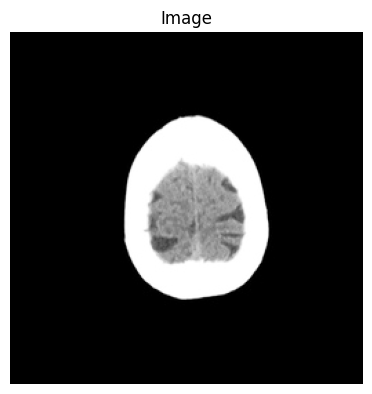

In [9]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 5))
# Display the original image
plt.subplot(1, 2, 1)
plt.imshow(image, cmap=plt.cm.Greys_r)
plt.title('Image')
plt.axis('off')
plt.show()

In [10]:
image.shape

(256, 256, 1)

In [11]:
sinogram = tf.squeeze(sinogram)

I0000 00:00:1750237525.918171      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1750237525.918819      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


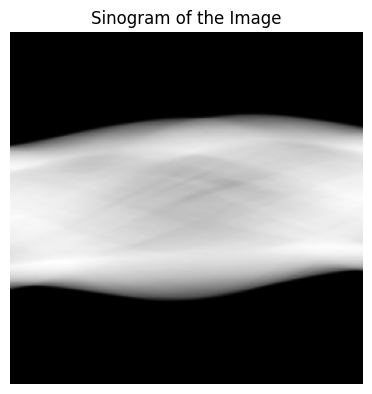

In [12]:
import numpy as np
plt.figure(figsize=(10, 5))
# Display the original image
plt.subplot(1, 2, 1)
plt.imshow(sinogram, cmap = plt.cm.Greys_r)
plt.title('Sinogram of the Image')
plt.axis('off')
plt.show()

In [13]:
sinogram.shape

TensorShape([256, 256])

In [14]:
# Build the model with the shape of the sinogram including the channel dimension
model = build_model(sinogram.shape, image.shape)

In [15]:
model.summary()

Model: "simpleCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 256, 256, 1)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 256, 256, 64)        │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 256, 256, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 256, 256, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 256, 256, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 256, 256, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 256, 256, 128)       │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 256, 256, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 256, 256, 128)       │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 256, 256, 256)       │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 256, 256, 256)       │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 256, 256, 128)       │         295,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 256, 256, 128)       │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 256, 256, 64)        │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 256, 256, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 256, 256, 1)         │             577 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lambda (Lambda)                      │ (None, 256, 256)            │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 926,913 (3.54 MB)

 Trainable params: 925,249 (3.53 MB)

 Non-trainable params: 1,664 (6.50 KB)

### Displaying Prediction on sample input

In [16]:
sinogram.shape

TensorShape([256, 256])

In [17]:
# Add batch dimension (axis=0) and channel dimension (axis=-1)
sinogram_for_prediction = np.expand_dims(np.expand_dims(sinogram, axis=0), axis=-1)
# Make a prediction using the model
prediction_sinogram = model.predict(sinogram_for_prediction)

I0000 00:00:1750237527.822405      60 service.cc:148] XLA service 0x7da930004280 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1750237527.823126      60 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1750237527.823146      60 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1750237527.956532      60 cuda_dnn.cc:529] Loaded cuDNN version 90300


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


I0000 00:00:1750237531.137146      60 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [18]:
prediction_sinogram.shape

(1, 256, 256)

In [19]:
prediction_sinogram = prediction_sinogram.squeeze()
prediction_sinogram.shape

(256, 256)

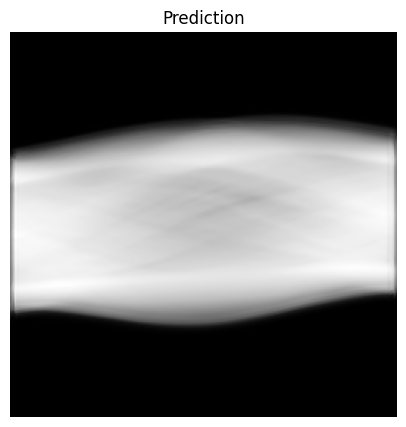

In [20]:
# Remove the batch dimension and single channel dimension from the prediction
# np.squeeze removes dimensions of size 1


plt.figure(figsize=(10, 5))
# Display the prediction
plt.subplot(1, 1, 1) # Use 1,1,1 for a single plot
plt.imshow(prediction_sinogram[1:], cmap = plt.cm.Greys_r)
plt.title('Prediction')
plt.axis('off')
plt.show()

In [21]:
model.compile(
    optimizer='adam',
    loss='mse',  # Mean Squared Error is a common loss for regression tasks like image reconstruction
    metrics=['mae'] # Mean Absolute Error is a useful metric to see the average pixel difference
)

In [22]:
history = model.fit(X_train, Y_train, epochs=10, batch_size=8)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 78s 3s/step - loss: 2.2958 - mae: 0.8839
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 510ms/step - loss: 0.1098 - mae: 0.2403
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 514ms/step - loss: 0.0950 - mae: 0.2264
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 522ms/step - loss: 0.0929 - mae: 0.2274
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 527ms/step - loss: 0.0883 - mae: 0.2159
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 534ms/step - loss: 0.0884 - mae: 0.2216
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 545ms/step - loss: 0.0930 - mae: 0.2220
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 555ms/step - loss: 0.0929 - mae: 0.2272
Epoch 9/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 559ms/step - loss: 0.0894 - mae: 0.2203
Epoch 10/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 555ms/step - loss: 0.0887 - mae: 0.2176


In [23]:
model.save('my_model.keras')

In [24]:
prediction_sinogram = model.predict(sinogram_for_prediction)
prediction_sinogram = prediction_sinogram.squeeze()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 533ms/step


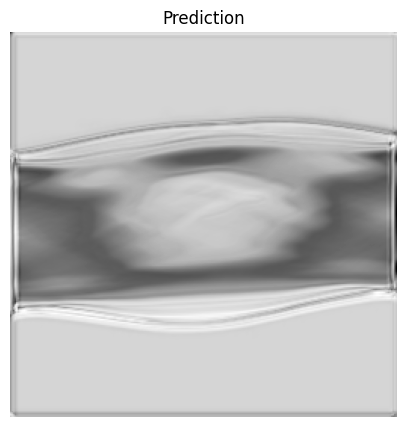

In [25]:
# Remove the batch dimension and single channel dimension from the prediction
# np.squeeze removes dimensions of size 1


plt.figure(figsize=(10, 5))
# Display the prediction
plt.subplot(1, 1, 1) # Use 1,1,1 for a single plot
plt.imshow(prediction_sinogram[1:], cmap = plt.cm.Greys_r)
plt.title('Prediction')
plt.axis('off')
plt.show()